In [1]:

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, errors
from qiskit.quantum_info import Pauli, state_fidelity
import numpy as np
import matplotlib.pyplot as plt


In [35]:

def create_multiple_bell_states(num_pairs):
    qc = QuantumCircuit(2 * num_pairs, 2 * num_pairs)  
    for i in range(num_pairs):
        qc.h(2 * i)        
        qc.cx(2 * i, 2 * i + 1)  
    return qc


In [36]:

def add_measurement(qc, angle, qubit, cbit):
    qc.ry(-2 * angle, qubit)  
    qc.measure(qubit, cbit)   


In [37]:

def compute_expectation(results, shots):
    counts = results.get_counts()
    print(f"Raw counts: {counts}")
    return (counts.get("00", 0) + counts.get("11", 0) - counts.get("01", 0) - counts.get("10", 0)) / shots

In [39]:

def compute_chsh_parameter_multiple_pairs(noise_model, time_steps, shots, num_pairs):
    angles = [0, np.pi / 4, np.pi / 2, -np.pi / 4]
    s_values = []
    all_s_values = []

    for t in time_steps:
        error = errors.amplitude_damping_error(1 - np.exp(-t))
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(error, ["id", "u1", "u2", "u3"])
        simulator = AerSimulator(noise_model=noise_model)

        s_total = 0
        s_individual = []
        for pair in range(num_pairs):
            expectations = []
            for angle1, angle2 in [(0, np.pi / 4), (0, -np.pi / 4), (np.pi / 2, np.pi / 4), (np.pi / 2, -np.pi / 4)]:
                qc = create_multiple_bell_states(num_pairs)
                qc.barrier()
                add_measurement(qc, angle1, 2 * pair, 2 * pair)
                add_measurement(qc, angle2, 2 * pair + 1, 2 * pair + 1)
                results = simulator.run(qc, shots=shots).result()
                expectation = compute_expectation(results, shots)
                expectations.append(expectation)

            print(f"Time {t}, Pair {pair+1}, Expectations: {expectations}")
            s = expectations[0] - expectations[1] + expectations[2] + expectations[3]
            print(f"Time {t}, Pair {pair+1}, S value: {s}")
            s_total += s
            s_individual.append(s)

        print(f"Time {t}, Average S value: {s_total / num_pairs}")
        s_values.append(s_total / num_pairs)
        all_s_values.append(s_individual)

    return s_values, all_s_values

In [40]:

time_steps = np.linspace(0, 5, 50)  
shots = 100024  
num_pairs = 3  

In [41]:

s_values, all_s_values = compute_chsh_parameter_multiple_pairs(NoiseModel(), time_steps, shots, num_pairs)


Raw counts: {'000001': 24904, '000010': 25010, '000000': 25043, '000011': 25067}
Raw counts: {'000001': 24884, '000010': 25178, '000000': 25045, '000011': 24917}
Raw counts: {'000001': 24939, '000011': 25081, '000010': 25140, '000000': 24864}
Raw counts: {'000001': 25072, '000010': 24948, '000000': 25009, '000011': 24995}
Time 0.0, Pair 1, Expectations: [0.0, 0.0, 0.0, 0.0]
Time 0.0, Pair 1, S value: 0.0
Raw counts: {'001100': 25029, '000100': 25135, '000000': 24908, '001000': 24952}
Raw counts: {'000100': 25198, '001000': 24775, '000000': 24993, '001100': 25058}
Raw counts: {'000100': 24920, '001100': 25070, '000000': 25127, '001000': 24907}
Raw counts: {'001100': 24858, '000100': 24867, '001000': 24984, '000000': 25315}
Time 0.0, Pair 2, Expectations: [0.0, 0.0, 0.0, 0.0]
Time 0.0, Pair 2, S value: 0.0
Raw counts: {'100000': 24974, '110000': 25136, '010000': 24798, '000000': 25116}
Raw counts: {'100000': 25115, '110000': 24686, '010000': 24955, '000000': 25268}
Raw counts: {'100000':

In [25]:

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

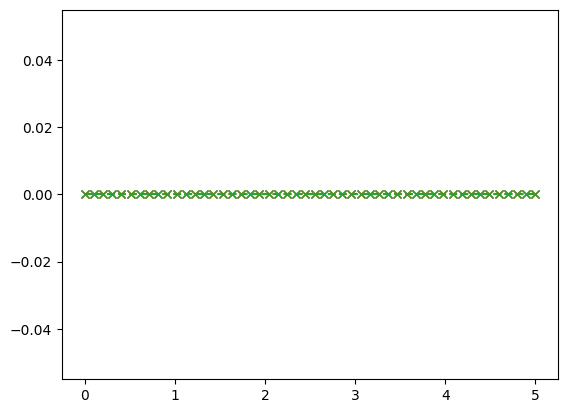

In [ ]:

for i in range(num_pairs):
    individual_s = [s[i] for s in all_s_values]
    plt.plot(time_steps, individual_s, label=f"Pair {i+1} S(t)", linestyle="--", marker="x")

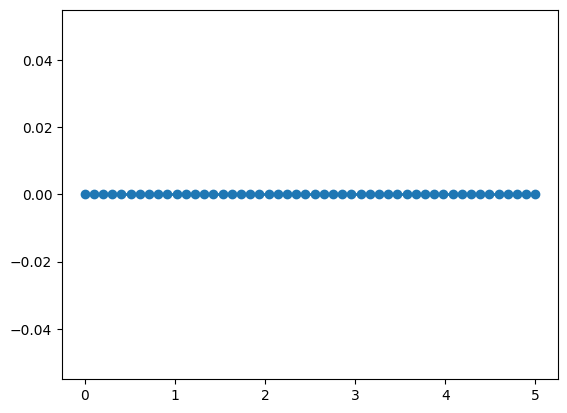

In [27]:

plt.plot(time_steps, s_values, label="Average S(t)", marker="o", linewidth=2)


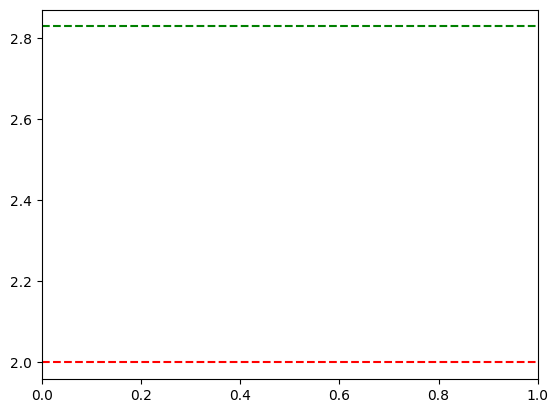

In [ ]:

plt.axhline(2, color="r", linestyle="--", label="Classical Limit")
plt.axhline(2 * np.sqrt(2), color="g", linestyle="--", label="Quantum Limit")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


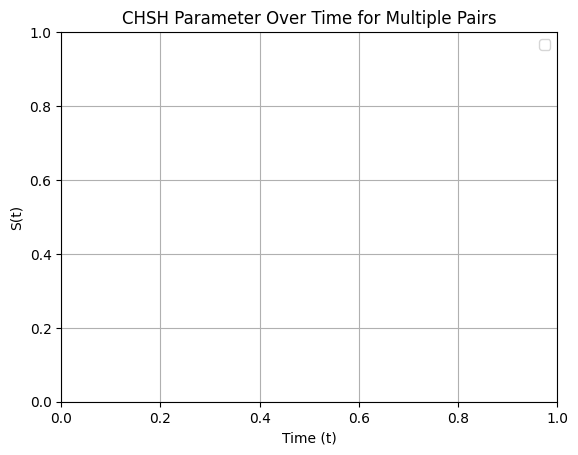

In [29]:

plt.xlabel("Time (t)")
plt.ylabel("S(t)")
plt.title("CHSH Parameter Over Time for Multiple Pairs")
plt.legend()
plt.grid()
plt.show()


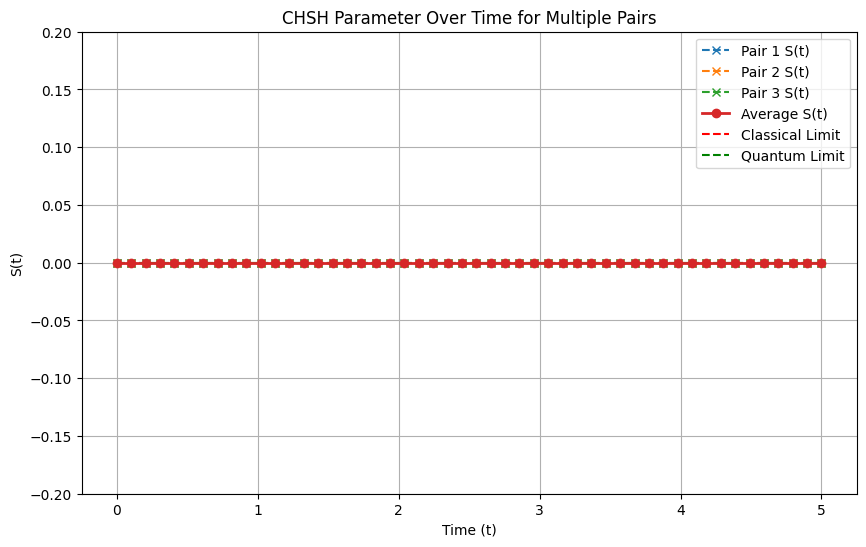

In [42]:

plt.figure(figsize=(10, 6))

for i in range(num_pairs):
    individual_s = [s[i] for s in all_s_values if len(s) > i]
    plt.plot(time_steps, individual_s, label=f"Pair {i+1} S(t)", linestyle="--", marker="x")

plt.plot(time_steps, s_values, label="Average S(t)", marker="o", linewidth=2)

plt.axhline(2, color="r", linestyle="--", label="Classical Limit")
plt.axhline(2 * np.sqrt(2), color="g", linestyle="--", label="Quantum Limit")

min_y = min(min(s_values), min([min(s) for s in all_s_values])) - 0.2
max_y = max(max(s_values), max([max(s) for s in all_s_values])) + 0.2
plt.ylim(min_y, max_y)

plt.xlabel("Time (t)")
plt.ylabel("S(t)")
plt.title("CHSH Parameter Over Time for Multiple Pairs")
plt.legend()
plt.grid()
plt.show()